In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
def euclidian_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [7]:
def knn_predict(X_train, y_train, X_test, k=3):
    predictions = []
    for test_point in X_test:
        # Compute distances from test_point to all training points
        distances = [euclidian_distance(test_point, train_point) for train_point in X_train]
        
        # Get indices of k neareast neighbors
        k_indices = np.argsort(distances)[:k]
        
        # Get labels of k nearest neighbors
        k_neighbor_labels = [y_train[i] for i in k_indices]
        
        # Majority vote
        most_common = Counter(k_neighbor_labels).most_common(1)
        
        predictions.append(most_common[0][0])
    
    return predictions

In [5]:
# Example dataset: X_train (data points), y_train (labels)
X_train = np.array([[1, 2], [2, 3], [3, 1], [5, 4], [6, 5]])
y_train = np.array([0, 0, 1, 1, 1]) # binary classification

# New test points
X_test = np.array([[3, 3], [5, 5]])

predictions = knn_predict(X_train, y_train, X_test, k=3)
print(f"Predicted labels: {predictions}")

Predicted labels: [np.int64(0), np.int64(1)]


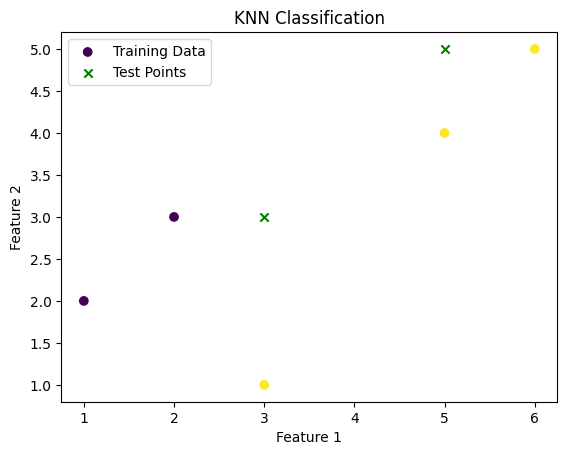

In [ ]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', label='Training Data')
plt.scatter(X_test[:, 0], X_test[:, 1], color='green', marker='x', label='Test Points')
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Classification")
plt.show()